In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances


In [2]:
# Set the random seed for reproducibility
np.random.seed(42)

In [3]:
df = pd.read_csv('chickwts.csv')

# Look at the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Get basic statistics
print("\nBasic statistics:")
print(df.describe())

# Get info
print("\nBasic statistics:")
print(df.info())

#Distribution
df['feed'].value_counts()

#Feed type caractersitics
df.groupby('feed')['weight'].describe().round(1)


First 5 rows of the dataset:
   rownames  weight       feed
0         1     179  horsebean
1         2     160  horsebean
2         3     136  horsebean
3         4     227  horsebean
4         5     217  horsebean

Missing values in the dataset:
rownames    0
weight      0
feed        0
dtype: int64

Basic statistics:
        rownames      weight
count  71.000000   71.000000
mean   36.000000  261.309859
std    20.639767   78.073700
min     1.000000  108.000000
25%    18.500000  204.500000
50%    36.000000  258.000000
75%    53.500000  323.500000
max    71.000000  423.000000

Basic statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  71 non-null     int64 
 1   weight    71 non-null     int64 
 2   feed      71 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.8+ KB
None


,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,12.0,323.6,64.4,216.0,277.2,342.0,370.8,404.0
horsebean,10.0,160.2,38.6,108.0,137.0,151.5,176.2,227.0
linseed,12.0,218.8,52.2,141.0,178.0,221.0,257.8,309.0
meatmeal,11.0,276.9,64.9,153.0,249.5,263.0,320.0,380.0
soybean,14.0,246.4,54.1,158.0,206.8,248.0,270.0,329.0
sunflower,12.0,328.9,48.8,226.0,312.8,328.0,340.2,423.0


There are 6 feed types with between 10 and 14 chicks each. `casein` and `sunflower` look like the "best" feeds on average (highest mean weight), `horsebean` looks like the worst.

In [4]:
agg = df.groupby('feed')['weight'].agg(
    mean_weight='mean',
    median_weight='median',
    std_weight='std',
    min_weight='min',
    max_weight='max',
).reset_index()

agg['q25'] = df.groupby('feed')['weight'].quantile(0.25).values
agg['q75'] = df.groupby('feed')['weight'].quantile(0.75).values
agg['iqr'] = agg['q75'] - agg['q25']
agg['cv'] = agg['std_weight'] / agg['mean_weight']
agg['skew'] = df.groupby('feed')['weight'].apply(lambda x: stats.skew(x)).values

print("Data with feature statistics")
print(agg)

Data with feature statistics
        feed  mean_weight  median_weight  std_weight  min_weight  max_weight  \
0     casein   323.583333          342.0   64.433840         216         404   
1  horsebean   160.200000          151.5   38.625841         108         227   
2    linseed   218.750000          221.0   52.235698         141         309   
3   meatmeal   276.909091          263.0   64.900623         153         380   
4    soybean   246.428571          248.0   54.129068         158         329   
5  sunflower   328.916667          328.0   48.836384         226         423   

      q25     q75    iqr        cv      skew  
0  277.25  370.75  93.50  0.199126 -0.524862  
1  137.00  176.25  39.25  0.241110  0.551319  
2  178.00  257.75  79.75  0.238792  0.010586  
3  249.50  320.00  70.50  0.234375 -0.282758  
4  206.75  270.00  63.25  0.219654  0.031232  
5  312.75  340.25  27.50  0.148476 -0.061816  


In [5]:
#Standardize features

feature_cols = ['mean_weight','median_weight','std_weight','min_weight','max_weight','q25','q75','iqr','cv','skew']
feeds = agg['feed'].values
X = agg[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=feature_cols, index=feeds).round(2)

,mean_weight,median_weight,std_weight,min_weight,max_weight,q25,q75,iqr,cv,skew
casein,1.09,1.29,1.17,1.18,0.89,0.85,1.28,1.38,-0.45,-1.45
horsebean,-1.68,-1.67,-1.68,-1.42,-1.79,-1.51,-1.77,-1.02,0.85,1.81
linseed,-0.68,-0.59,-0.18,-0.63,-0.55,-0.82,-0.49,0.77,0.78,0.17
meatmeal,0.30,0.06,1.22,-0.34,0.52,0.38,0.48,0.36,0.64,-0.72
soybean,-0.22,-0.17,0.03,-0.22,-0.25,-0.34,-0.30,0.04,0.19,0.23
sunflower,1.18,1.07,-0.55,1.42,1.17,1.44,0.80,-1.53,-2.01,-0.05


Variance explained by each principal component:
  Principal Component    Eigenvalue  Variance Explained (%)  \
0                 PC1  9.155450e+00            7.629542e+01   
1                 PC2  2.552123e+00            2.126769e+01   
2                 PC3  2.686921e-01            2.239101e+00   
3                 PC4  1.470540e-02            1.225450e-01   
4                 PC5  9.029524e-03            7.524603e-02   
5                 PC6  5.693151e-32            4.744293e-31   

   Cumulative Variance Explained (%)  
0                          76.295420  
1                          97.563108  
2                          99.802209  
3                          99.924754  
4                         100.000000  
5                         100.000000  


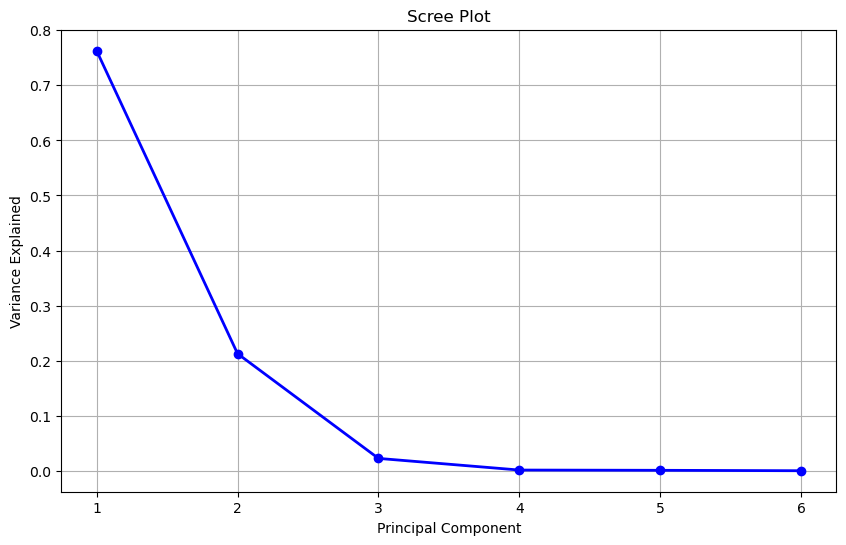

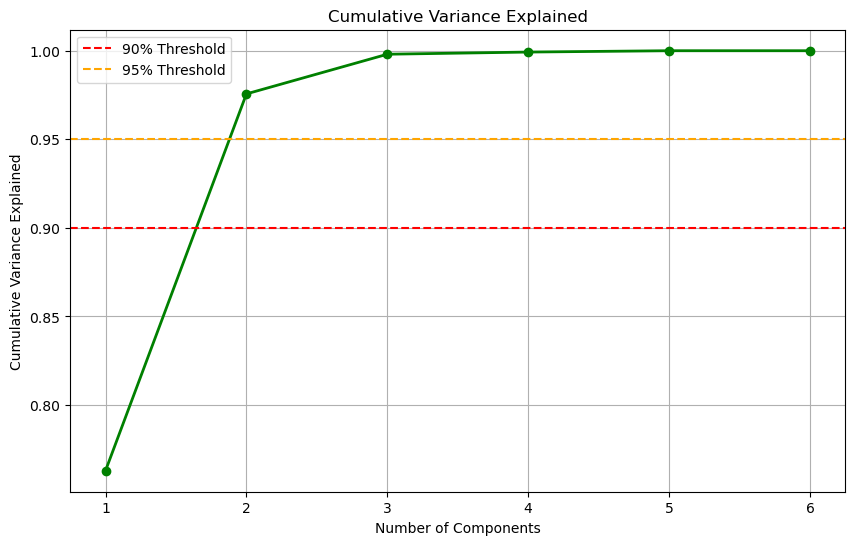

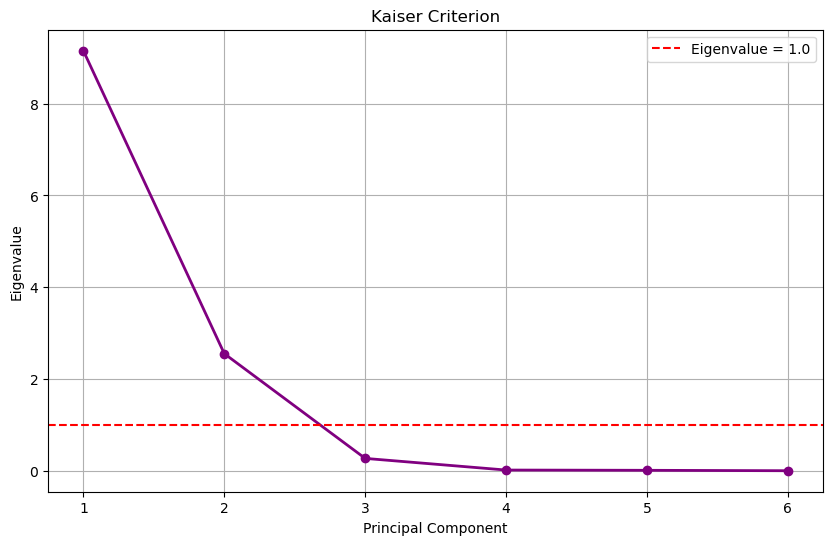

In [6]:
pca = PCA()
pca.fit(X_scaled)

# Examine explained variance
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Create a dataframe for better display
variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Eigenvalue': explained_variance,
    'Variance Explained (%)': explained_variance_ratio * 100,
    'Cumulative Variance Explained (%)': cumulative_variance_ratio * 100
})

print("Variance explained by each principal component:")
print(variance_df)

# Create scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

# Create cumulative variance plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'o-', linewidth=2, color='green')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Threshold')
plt.title('Cumulative Variance Explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

# Create Kaiser criterion plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'o-', linewidth=2, color='purple')
plt.axhline(y=1.0, color='r', linestyle='--', label='Eigenvalue = 1.0')
plt.title('Kaiser Criterion')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True)
plt.show()

PC1 and PC2 together explain about 97-98% of the variance, so I'll just keep those two for the similarity comparison and for plotting — that's a good trade-off between simplicity and not losing information (and honestly with only 6 feeds, going to more components doesn't add much anyway).

In [7]:
pca = PCA(n_components=2)
pc_scores = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(pc_scores, columns=['PC1','PC2'])
pc_df.insert(0, 'feed', feeds)
print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
pc_df

PC1 explains 76.3% of variance
PC2 explains 21.3% of variance


,feed,PC1,PC2
0,casein,3.350949,1.179376
1,horsebean,-4.827741,-0.882644
2,linseed,-1.558705,1.041730
3,meatmeal,0.927523,1.289279
4,soybean,-0.638595,0.167796
5,sunflower,2.746569,-2.795537


In [8]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=feature_cols)
loadings.round(2)

,PC1,PC2
mean_weight,0.36,-0.07
median_weight,0.36,-0.04
std_weight,0.26,0.45
min_weight,0.34,-0.19
max_weight,0.36,-0.05
q25,0.35,-0.17
q75,0.36,0.07
iqr,0.10,0.63
cv,-0.26,0.47
skew,-0.32,-0.30


Looking at the loadings: PC1 is basically an overall "performance" axis — mean/median/min/max/quartiles all load positively and strongly, while `skew` and `cv` load negatively. So high PC1 = heavier, more consistent chicks. PC2 is driven mostly by `iqr`, `cv` and `std_weight`, so it captures how *variable/spread out* a feed's results are, independent of the average.

## 5. Similarity metrics & recommendation engine

Now the actual business ask: given a feed, recommend the most *similar* feed(s) in terms of performance profile. I'll compute two standard similarity/distance metrics on the PCA scores:

- **Euclidean distance** — straight-line distance between feed profiles in PC space. Smaller = more similar. This is my main metric for recommendations because "close in performance-profile space" is exactly what we want.
- **Cosine similarity** — angle between feed vectors. Included as a sanity check/alternative view.

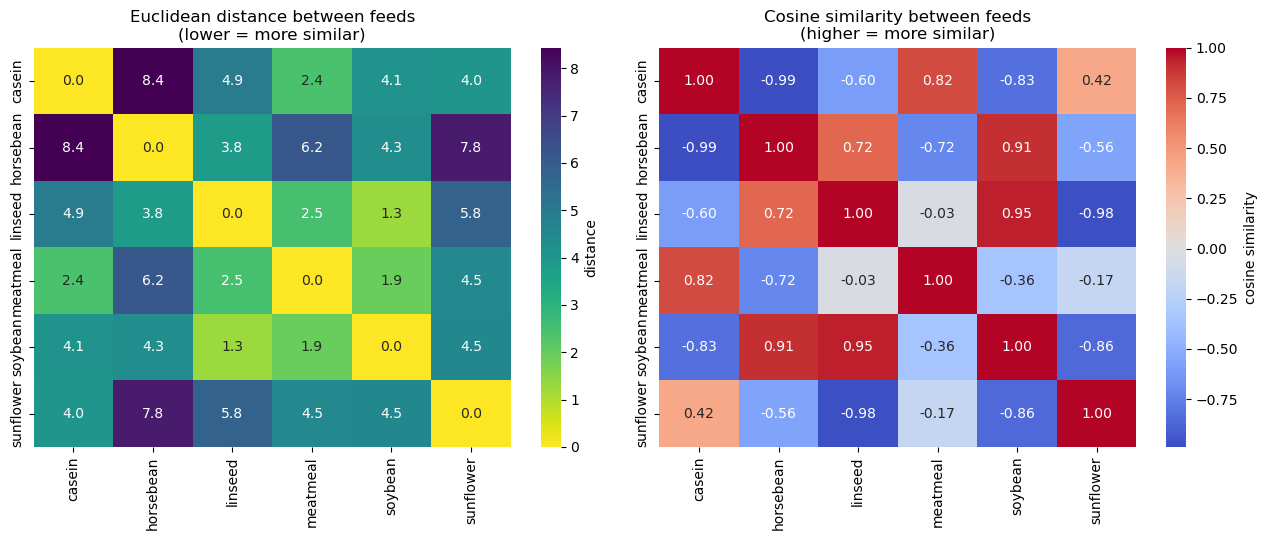

In [9]:
euc_dist = euclidean_distances(pc_scores)
euc_df = pd.DataFrame(euc_dist, index=feeds, columns=feeds)

cos_sim = cosine_similarity(pc_scores)
cos_df = pd.DataFrame(cos_sim, index=feeds, columns=feeds)

euc_df.round(2)

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

sns.heatmap(euc_df, annot=True, fmt='.1f', cmap='viridis_r', ax=axes[0], cbar_kws={'label':'distance'})
axes[0].set_title('Euclidean distance between feeds\n(lower = more similar)')

sns.heatmap(cos_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label':'cosine similarity'})
axes[1].set_title('Cosine similarity between feeds\n(higher = more similar)')

plt.tight_layout()
plt.show()

In [10]:
def recommend_similar_feed(feed_name, n=2, metric='euclidean'):
    """Recommend the n most similar feeds to feed_name based on PCA profile."""
    if feed_name not in feeds:
        raise ValueError(f"'{feed_name}' not found. Options: {list(feeds)}")

    if metric == 'euclidean':
        scores = euc_df.loc[feed_name].drop(feed_name).sort_values()  # smaller = more similar
    elif metric == 'cosine':
        scores = cos_df.loc[feed_name].drop(feed_name).sort_values(ascending=False)  # bigger = more similar
    else:
        raise ValueError("metric must be 'euclidean' or 'cosine'")

    return scores.head(n)

print("If a farmer is currently using CASEIN, recommend similar feeds:")
print(recommend_similar_feed('casein'))
print()
print("If a farmer is currently using HORSEBEAN, recommend similar feeds:")
print(recommend_similar_feed('horsebean'))

If a farmer is currently using CASEIN, recommend similar feeds:
meatmeal     2.425917
sunflower    4.020598
Name: casein, dtype: float64

If a farmer is currently using HORSEBEAN, recommend similar feeds:
linseed    3.793390
soybean    4.318838
Name: horsebean, dtype: float64


In [11]:
print("Top recommendation for every feed (euclidean, PCA space):\n")
for f in feeds:
    top = recommend_similar_feed(f, n=1)
    print(f"  {f:>10s}  -->  {top.index[0]:<10s}  (distance = {top.values[0]:.2f})")

Top recommendation for every feed (euclidean, PCA space):

      casein  -->  meatmeal    (distance = 2.43)
   horsebean  -->  linseed     (distance = 3.79)
     linseed  -->  soybean     (distance = 1.27)
    meatmeal  -->  soybean     (distance = 1.93)
     soybean  -->  linseed     (distance = 1.27)
   sunflower  -->  casein      (distance = 4.02)


## 7. Conclusions & limitations

- Because chick weights only give one measurable outcome per animal, I had to aggregate to the feed level and engineer multiple descriptive features (mean, spread, shape) before PCA was meaningful. In a real deployment, the agri-supply company would ideally have several outcome variables per feed batch (weight gain, feed conversion ratio, mortality, cost per kg, etc.), which would make the PCA much richer and less dependent on stats derived from a single variable.
- With only 6 feed "items", this is a toy-scale recommender — in production you'd want many more feed products and multiple performance metrics to get robust, non-trivial recommendations.
- The recommendation function (`recommend_similar_feed`) is generic — it works off the `euc_df`/`cos_df` similarity matrices, so it would scale directly to a bigger feed catalogue if more feed types/metrics were added.
- **Business takeaway:** if a farmer likes casein or sunflower's results, meatmeal is the closest substitute; if they're using a lower-performing feed like horsebean, there isn't a great close substitute in this dataset — the next best option (linseed) is still a meaningful step down.